# Modelagem — prevendo dengue em Porto Alegre (até 12 semanas à frente)

Consome a **`tabela_final.csv`** (montada no `montagem_da_tabela.ipynb`) e treina um modelo que **prevê os casos semana a semana, até 3 meses (12 semanas) à frente**.

A metodologia segue o modelo de **Sortimento (Panvel)**: **estratégia direta multi-horizonte** + **validação walk-forward**. Tudo didático e isolado em blocos.

## 1. Ambiente

In [1]:
import importlib.util as u
for m in ["pandas", "numpy", "matplotlib", "sklearn", "lightgbm"]:
    print(f"{m:12s}", "OK" if u.find_spec(m) else "FALTA  ->  pip install")

pandas       OK
numpy        OK
matplotlib   OK
sklearn      OK
lightgbm     OK


## 2. Carregar a tabela

Uma linha por semana epidemiológica (vetor + clima + casos + ENSO). São **dois blocos** no tempo — Marília (2019–2023) e raspagem (2025–2026) — com um **gap** no meio.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd


def achar_raiz(marcador="Raspagem"):
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / marcador).is_dir():
            return p
    raise FileNotFoundError(f"Pasta-raiz contendo '{marcador}/' nao encontrada a partir de {Path.cwd()}")


RAIZ = achar_raiz()
TABELA = RAIZ / "Bases de dados" / "tabela_modelagem" / "tabela_final.csv"

df = pd.read_csv(TABELA, parse_dates=["data_inicio_semana_epidemi"])
df = df.sort_values(["fonte", "data_inicio_semana_epidemi"]).reset_index(drop=True)
pd.set_option("display.max_columns", None)

print("tabela_final:", df.shape, "| blocos:", df["fonte"].value_counts().sort_index().to_dict())
df.head(3)

tabela_final: (276, 36) | blocos: {'marilia': 232, 'raspagem': 44}


,fonte,SE,data_inicio_semana_epidemi,ano,semana,numero_de_armadilhas,aedes_aegypti,aedes_albopictus,culex_sp,aedes_aegypti_por_armadilha,interpolado,precip_total_mm,precip_max_dia_mm,precip_media_dia_mm,dias_de_chuva,temp_media,temp_min,temp_max,temp_amplitude_media,orvalho_min,orvalho_media,orvalho_max,umid_min,umid_media,umid_max,pressao_min,pressao_media,pressao_max,radiacao_min,radiacao_media,radiacao_max,vento_media,vento_max,casos_confirmados,nino34_anom,oni
0,marilia,201901,2018-12-30,2019,1,1292,55,1,128,0.042570,False,20.72,13.13,2.960000,3.0,25.848571,18.14,35.91,9.628571,17.91,21.871429,24.47,75.56,79.912857,86.06,100.29,100.605714,100.93,9.36,20.837143,28.12,3.535714,4.96,1.0,0.89,0.92
1,marilia,201902,2019-01-06,2019,2,1364,57,10,180,0.041789,False,17.34,5.03,2.477143,5.0,25.617143,21.15,32.27,7.478571,21.09,22.595714,24.14,79.57,84.040000,85.84,100.04,100.678571,101.16,10.08,15.892857,28.11,3.797143,4.99,0.0,0.65,0.89
2,marilia,201903,2019-01-13,2019,3,1365,455,46,628,0.333333,False,60.59,18.80,8.655714,7.0,25.478571,18.63,31.31,6.652857,18.46,22.800000,24.66,82.09,85.840000,90.33,100.48,100.737143,101.01,9.35,17.654286,26.10,3.802857,6.42,2.0,0.65,0.89


## 3. A estratégia (igual ao Sortimento)

Queremos prever **12 semanas à frente**. A forma usada no Sortimento é a **estratégia DIRETA multi-horizonte**:

> Em vez de 1 modelo, treinamos **um modelo por horizonte**: o modelo `h=1` aprende a prever os casos de daqui a 1 semana; o `h=2`, de 2 semanas; … até o `h=12`. Cada um usa **as mesmas features de hoje** (a "âncora") e prevê o seu horizonte de forma **isolada** — **não** realimentamos previsões (isso seria recursivo e acumularia erro).

Cada horizonte é avaliado com **walk-forward** (treina no passado → prevê o futuro → expande a janela), comparando sempre com a **persistência** ("daqui a h semanas teremos os mesmos casos de hoje").

**O que do Sortimento NÃO se aplica aqui:** lá há roteamento por magnitude (Tweedie/Quantile), α adaptativo e travas de série morta — tudo isso existe porque o Sortimento tem **milhares de séries item×loja intermitentes**. Aqui temos **uma série semanal da cidade**, então mantemos um único LightGBM por horizonte.

**Detalhe fiel ao Sortimento:** adicionamos a sazonalidade da **semana-alvo** (t+h) como feature — o análogo do `target_mes` de lá (o modelo "sabe" se a semana que está prevendo é de verão ou inverno).

## 4. Features (no momento da previsão)

Features são o que sabemos **hoje** (na âncora): valores atuais + **lags 1–4 semanas** de casos/vetor/clima + médias móveis + sazonalidade. Tudo calculado **por bloco** (`groupby('fonte')`) pra não vazar pelo gap.

In [3]:
g = df.groupby("fonte", group_keys=False)

para_lag = ["casos_confirmados", "aedes_aegypti_por_armadilha",
            "temp_media", "precip_total_mm", "orvalho_media", "umid_media", "pressao_media"]
for col in para_lag:
    for k in [1, 2, 3, 4]:
        df[f"{col}_lag{k}"] = g[col].shift(k)

df["casos_mm4"] = g["casos_confirmados"].transform(lambda s: s.rolling(4).mean())
df["vetor_mm4"] = g["aedes_aegypti_por_armadilha"].transform(lambda s: s.rolling(4).mean())
df["sem_sin"] = np.sin(2 * np.pi * df["semana"] / 52)
df["sem_cos"] = np.cos(2 * np.pi * df["semana"] / 52)

# features = tudo, menos identificadores (o alvo de cada horizonte é criado na hora)
nao_features = ["fonte", "SE", "data_inicio_semana_epidemi", "ano", "semana", "interpolado"]
features_base = [c for c in df.columns if c not in nao_features]
print(f"{len(features_base)} features-base (âncora)")

62 features-base (âncora)


## 5. Função: previsão multi-horizonte com walk-forward

Para cada horizonte `h`: cria o alvo `casos[t+h]` (por bloco), adiciona a sazonalidade da semana-alvo, e roda o walk-forward (treina em tudo até *i*, prevê *i*; expande). Guarda o real, a previsão do LightGBM e a persistência.

In [4]:
from lightgbm import LGBMRegressor

PARAMS = dict(n_estimators=250, learning_rate=0.05, num_leaves=15,
              min_child_samples=5, verbose=-1, n_jobs=-1)


def previsao_multihorizonte(df, features_base, alvo="casos_confirmados",
                            horizontes=range(1, 13), min_treino=104, passo=1):
    """Estratégia DIRETA: um modelo por horizonte, avaliado com walk-forward.
    passo=1 -> testa toda semana (mais lento, ~10 min). Aumente p/ iterar rápido."""
    g = df.groupby("fonte", group_keys=False)
    linhas = []
    for h in horizontes:
        d = df.copy()
        d["y_h"] = g[alvo].shift(-h)                       # casos daqui a h semanas (por bloco)
        semana_alvo = g["semana"].shift(-h)               # sazonalidade da semana prevista
        d["alvo_sin"] = np.sin(2 * np.pi * semana_alvo / 52)
        d["alvo_cos"] = np.cos(2 * np.pi * semana_alvo / 52)
        feats = features_base + ["alvo_sin", "alvo_cos"]
        dh = d.dropna(subset=feats + ["y_h"]).sort_values("data_inicio_semana_epidemi").reset_index(drop=True)
        for i in range(min_treino, len(dh), passo):
            tr, te = dh.iloc[:i], dh.iloc[i:i + 1]
            modelo = LGBMRegressor(**PARAMS).fit(tr[feats], tr["y_h"])
            linhas.append({"h": h,
                           "data": te["data_inicio_semana_epidemi"].values[0],
                           "real": te["y_h"].values[0],
                           "pred": modelo.predict(te[feats])[0],
                           "naive": te[alvo].values[0]})
    return pd.DataFrame(linhas)


print("função pronta")

função pronta


## 6. Rodar (h = 1 … 12) — com cache

⏱️ Com `PASSO=1` (uma origem por semana) são ~1.750 ajustes de LightGBM → **~10 minutos na 1ª vez**. Depois disso o resultado fica **salvo em disco** (`cache_modelo1/`) e a célula apenas **carrega** — instantâneo.

- O cache **se invalida sozinho**: o nome do arquivo carrega uma impressão digital da tabela + `PARAMS` + features + `PASSO`. Mudou algo relevante → recomputa automaticamente.
- `FORCAR = True` força recomputar do zero, ignorando o cache.
- Pra iterar mais rápido durante testes, use `PASSO=2` ou `PASSO=4` (cada PASSO gera seu próprio cache).

In [ ]:
import hashlib

# Cache: na 1ª vez gera e salva; nas próximas, carrega do disco (não recomputa os ~10 min).
CACHE_DIR = RAIZ / "Bases de dados" / "tabela_modelagem" / "cache_modelo1"
CACHE_DIR.mkdir(exist_ok=True)
PASSO = 1        # 1 = uma origem por semana (~10 min). Aumente (2, 4) p/ iterar mais rápido.
FORCAR = False   # True = ignora o cache e recomputa do zero


def _fingerprint():
    """Impressão digital dos insumos. Muda (e invalida o cache sozinho) se a tabela,
    os PARAMS, as features ou o PASSO mudarem — sem risco de reportar número velho."""
    chave = pd.util.hash_pandas_object(df[features_base], index=False).values.tobytes()
    extra = repr((sorted(features_base), PARAMS, PASSO)).encode()
    return hashlib.md5(chave + extra).hexdigest()[:12]


cache = CACHE_DIR / f"resultado_passo{PASSO}_{_fingerprint()}.csv"

if cache.exists() and not FORCAR:
    resultado = pd.read_csv(cache, parse_dates=["data"])
    print(f"✔ carregado do cache: {cache.name} ({len(resultado)} linhas) — não recomputou")
else:
    resultado = previsao_multihorizonte(df, features_base, passo=PASSO)
    resultado.to_csv(cache, index=False)
    print(f"✔ gerado e salvo: {cache.name} ({len(resultado)} linhas)")

print("horizontes:", sorted(resultado["h"].unique()))
resultado.head()

## 7. Erro por horizonte — LightGBM vs persistência

Onde o modelo passa a valer a pena? Comparamos o erro (MAE) e o R² em cada horizonte.

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

metricas = resultado.groupby("h").apply(lambda x: pd.Series({
    "MAE_lightgbm": mean_absolute_error(x["real"], x["pred"]),
    "MAE_persist": mean_absolute_error(x["real"], x["naive"]),
    "R2_lightgbm": r2_score(x["real"], x["pred"]),
    "R2_persist": r2_score(x["real"], x["naive"]),
}), include_groups=False).round(2)

ganha = metricas[metricas["MAE_lightgbm"] < metricas["MAE_persist"]].index.tolist()
print("LightGBM bate a persistência (MAE) nos horizontes:", ganha)
metricas

LightGBM bate a persistência (MAE) nos horizontes: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


,MAE_lightgbm,MAE_persist,R2_lightgbm,R2_persist
h,,,,
1,27.78,22.09,0.86,0.89
2,34.80,37.63,0.80,0.72
3,39.59,50.28,0.73,0.55
4,50.98,62.42,0.58,0.34
5,64.42,71.91,0.33,0.13
6,61.43,81.66,0.37,-0.06
7,68.68,90.06,0.27,-0.24
8,68.34,97.37,0.29,-0.39
9,66.06,103.82,0.34,-0.50


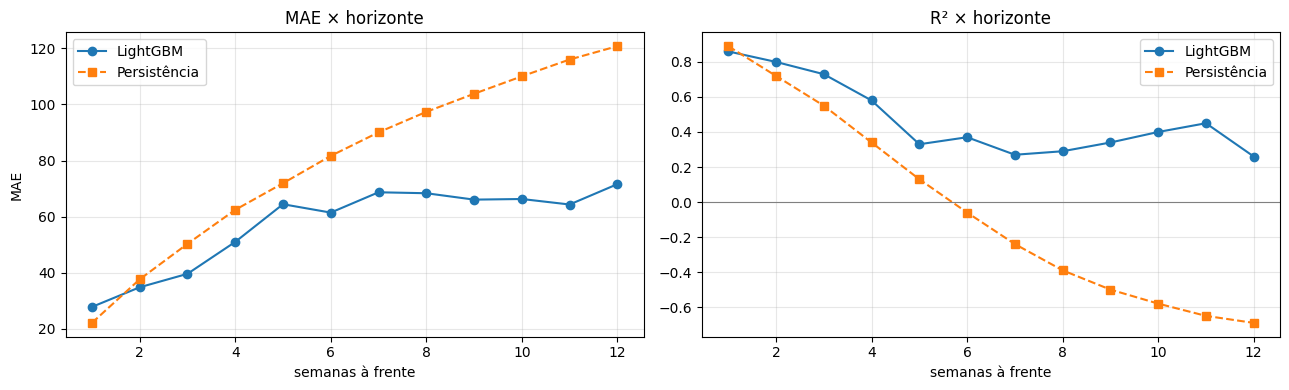

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(metricas.index, metricas["MAE_lightgbm"], "o-", label="LightGBM")
ax[0].plot(metricas.index, metricas["MAE_persist"], "s--", label="Persistência")
ax[0].set_title("MAE × horizonte"); ax[0].set_xlabel("semanas à frente"); ax[0].set_ylabel("MAE"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(metricas.index, metricas["R2_lightgbm"], "o-", label="LightGBM")
ax[1].plot(metricas.index, metricas["R2_persist"], "s--", label="Persistência")
ax[1].axhline(0, color="gray", lw=0.8)
ax[1].set_title("R² × horizonte"); ax[1].set_xlabel("semanas à frente"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Leitura dos resultados

- **No horizonte de 1 semana, a persistência ganha** ("a semana que vem ≈ esta"). Esperado: dengue muda devagar de uma semana pra outra.
- **A partir de 2 semanas, o LightGBM passa a vencer — e a vantagem só cresce.** A persistência **desmorona** (R² fica negativo a partir de ~6 semanas, ou seja, pior do que chutar a média), enquanto o LightGBM **mantém skill útil** (R² ~0,3–0,45) até 12 semanas.
- **É exatamente a tese:** o sinal **antecipatório** (clima + vetor + lags) prova seu valor nos **horizontes longos** — justo onde a vigilância precisa (planejar com semanas de antecedência).

> Ressalvas honestas: série curta (≈260 semanas, 2 blocos com gap), casos de 2026 ainda incompletos (*right-censoring*), e ainda **não** isolamos o quanto vem do vetor vs do clima — é o próximo passo.

## 9. Próximos passos

- **Lift entomológico:** rodar o mesmo multi-horizonte com **só-clima** vs **clima + vetor** e medir o ganho por horizonte (o diferencial da tese — o valor do MI-Aedes).
- **SHAP** por horizonte (ver o peso das features de armadilha crescer com `h`).
- **Tunar** o LightGBM e comparar com SARIMAX/CatBoost.
- **Forecast "ao vivo":** treinar nos dados todos e cuspir a trajetória das próximas 12 semanas a partir da última âncora.
- **Decidir o alvo** (casos vs vetor) com o orientador; subir pra nível bairro se vier o dado.